# AI Project
Group 1: Nicolò Ferrari, Luca Palumbo, Lorenzo Meloncelli, Antonio Fontanella

Task: The aim of this assignment is to investigate **whether, by developing a text classifier (or other ML-based predictor) on financial news headlines**, **it is possible to explain** (after-the-fact) the **price movements** on the stock market on that day.

## Approach

We frame the problem as a **supervised text classification task**: given the financial news headlines published on a given trading day, we train a BERT + LoRA model to predict the direction of that day's market movement:
- positive
- negative
- no_change

The pipeline consists of four main steps:
1. **Data collection**: financial headlines paired with same-day price movements
2. **Feature extraction**: a BERT + LoRA backbone fine-tuned on a financial-sentiment dataset
3. **Classification**: train 2 different models (a linear probe and a stacked LoRA) on our price-labeled headlines
4. **Analysis**: compare the models to a dummy baseline and cross-validate the LoRA rank

# 1. Environment Setup

In [ ]:
!pip install -q -U transformers accelerate bitsandbytes kaggle peft datasets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.8/132.8 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.0/231.0 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 16.1 MB/s eta 0:00:00


In [ ]:
!pip install --upgrade torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 45.6 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [ ]:
import os
import warnings
warnings.filterwarnings('ignore')
import gc
import shutil
import copy


# Data
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Hugging Face / PyTorch
import torch
from torch import nn
from huggingface_hub import login
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    set_seed
)
from peft import PeftModel, LoraConfig, TaskType, get_peft_model
from peft.tuners.tuners_utils import BaseTunerLayer
from peft.utils.other import ModulesToSaveWrapper
from datasets import Dataset
from datasets import load_dataset
from collections import Counter


# Sklearn
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.utils.class_weight import compute_class_weight
from tqdm.auto import tqdm
from transformers.trainer_callback import EarlyStoppingCallback

# Make results reproducible
RANDOM_SEED = 42

# 2. Download the news-headline dataset from Kaggle

Instead of pulling a live RSS feed from Google News, we use a ready-made dataset of financial news headlines (**"Massive Stock News Analysis"**) found on Kaggle. For our purpose it is *unlabeled*: it ships only the headline text and date, so we attach our own labels later by matching each headline to its stock's same-day price move (Section 3).

These headlines are the data for the **downstream price-direction task** (Models 1 and 2). The sentiment backbone itself is trained separately, on a labeled financial-sentiment dataset (Twitter Financial News, Section 6).

In [ ]:
!kaggle datasets download -d miguelaenlle/massive-stock-news-analysis-db-for-nlpbacktests

!unzip massive-stock-news-analysis-db-for-nlpbacktests.zip

Dataset URL: https://www.kaggle.com/datasets/miguelaenlle/massive-stock-news-analysis-db-for-nlpbacktests
License(s): CC0-1.0
100% 210M/210M [00:04<00:00, 48.5MB/s]

Archive:  massive-stock-news-analysis-db-for-nlpbacktests.zip
  inflating: analyst_ratings_processed.csv  
  inflating: raw_analyst_ratings.csv  
  inflating: raw_partner_headlines.csv  


In [ ]:
df = pd.read_csv('analyst_ratings_processed.csv')
df = df.dropna()
df = df.drop(columns=['Unnamed: 0'])
df['date'] = pd.to_datetime(df['date'],utc=True)
print(f'Data range: {df["date"].min()} to {df["date"].max()}')
print(f'Number of unique stocks: {len(df["stock"].unique())}')
df.sample(10)

Data range: 2009-02-14 19:02:00+00:00 to 2020-06-11 21:12:00+00:00
Number of unique stocks: 6192


,title,date,stock
121448,AXIS Capital Late Wednesday Reported Q1 EPS $1...,2018-04-26 13:12:00+00:00,AXS
1048046,Macquarie Upgrades Quad/Graphics To Outperform,2017-03-29 11:11:00+00:00,QUAD
980354,Depomed Call: 'Our First Priority is to Look f...,2013-10-21 21:14:00+00:00,PDLI
11060,Acorn Energy Updates 2010 Revenue Guidance,2010-10-20 14:14:00+00:00,ACFN
814004,Podcast | How To Screen For Cheap 'Old Economy...,2019-04-25 18:00:00+00:00,MIC
755096,Benzinga's Biotech Pulse: Pfizer's Xeljanz Get...,2018-08-01 13:01:00+00:00,LLY
1289010,"Earnings Scheduled For May 1, 2019",2019-05-01 09:05:00+00:00,UTHR
52407,Steel Stocks Trading Higher Across The Board: ...,2017-05-23 15:48:00+00:00,AKS
446195,Hearing Director Of White House National Trade...,2018-10-01 11:44:00+00:00,EWC
833009,"May 23, 2011: A Stockless Portfolio? Yes We Can",2011-05-19 16:29:00+00:00,MOO


In [ ]:
# Focus on 5 stocks: GOOG, TSLA, NVDA, KO, NFLX
alphabet_data = df[df['stock'] == 'GOOG'].copy().reset_index(drop=True).sort_values('date')
print(f'GOOG news: {len(alphabet_data)}')
print(f'GOOG date range: {alphabet_data["date"].min()} to {alphabet_data["date"].max()}')
tsla_data = df[df['stock'] == 'TSLA'].copy().reset_index(drop=True).sort_values('date')
print(f'TSLA news: {len(tsla_data)}')
print(f'TSLA date range: {tsla_data["date"].min()} to {tsla_data["date"].max()}')
nvda_data = df[df['stock'] == 'NVDA'].copy().reset_index(drop=True).sort_values('date')
print(f'NVDA news: {len(nvda_data)}')
print(f'NVDA date range: {nvda_data["date"].min()} to {nvda_data["date"].max()}')
coca_cola_data = df[df['stock'] == 'KO'].copy().reset_index(drop=True).sort_values('date')
print(f'KO news: {len(coca_cola_data)}')
print(f'KO date range: {coca_cola_data["date"].min()} to {coca_cola_data["date"].max()}')
nflx_data = df[df['stock'] == 'NFLX'].copy().reset_index(drop=True).sort_values('date')
print(f'NFLX news: {len(nflx_data)}')
print(f'NFLX date range: {nflx_data["date"].min()} to {nflx_data["date"].max()}')

GOOG news: 1209
GOOG date range: 2018-11-13 15:30:00+00:00 to 2020-06-10 19:25:00+00:00
TSLA news: 1930
TSLA date range: 2019-07-01 15:29:00+00:00 to 2020-06-10 21:02:00+00:00
NVDA news: 3133
NVDA date range: 2011-03-03 15:06:00+00:00 to 2020-06-10 16:37:00+00:00
KO news: 2785
KO date range: 2009-06-23 00:39:00+00:00 to 2020-06-11 14:55:00+00:00
NFLX news: 3009
NFLX date range: 2016-08-23 12:41:00+00:00 to 2020-06-10 20:20:00+00:00


In [ ]:
# Merge all 5 stocks into a single DataFrame
stocks_data = pd.concat([alphabet_data, tsla_data, nvda_data, coca_cola_data, nflx_data], ignore_index=True).sort_values('date').reset_index(drop=True)
print(f'Total news for 5 stocks: {len(stocks_data)}')
print(f'Overall date range: {stocks_data["date"].min()} to {stocks_data["date"].max()}')
stocks_data.sample(10)

Total news for 5 stocks: 12066
Overall date range: 2009-06-23 00:39:00+00:00 to 2020-06-11 14:55:00+00:00


,title,date,stock
464,CEOWORLD top 6 buy Materials stocks list for 2...,2011-04-28 13:26:00+00:00,NVDA
8270,"Bank Of America, Citing SensorTower, Says Netf...",2019-09-09 13:17:00+00:00,NFLX
2692,"BoA Likes Avago, Intel And Others Semiconducto...",2016-03-21 13:48:00+00:00,NVDA
56,A Look At How Different Sectors Will Behave In...,2010-02-09 19:58:00+00:00,KO
7515,The IMX Reaches A Six-Month High After May's V...,2019-06-10 19:00:00+00:00,NFLX
8691,Coca-Cola shares are trading higher after the ...,2019-10-18 12:18:00+00:00,KO
7768,A Peek Into The Markets: US Stock Futures Fall...,2019-07-18 10:25:00+00:00,NFLX
4835,NVIDIA Announces Collaboration with Taiwan's M...,2017-10-26 07:53:00+00:00,NVDA
9248,'Tesla Gigafactory 3 starts producing a lot of...,2019-12-03 11:48:00+00:00,TSLA
9093,PreMarket Prep Recap: Breaking Down The Reacti...,2019-11-15 18:47:00+00:00,NVDA


# 3. Dataset EDA and labeling with a 1% threshold on % price change

In [ ]:
# Dowload close price for each stock selected from yfinance
tickers = ['GOOG', 'TSLA', 'NVDA', 'KO', 'NFLX']
start_date = stocks_data['date'].min()
end_date = stocks_data['date'].max()
price_data = yf.download(tickers, start=start_date, end=end_date, group_by='ticker')
price_data = pd.concat([price_data[ticker]['Close'].rename(ticker) for ticker in tickers], axis=1)
price_data.head()

[*********************100%***********************]  5 of 5 completed


,GOOG,TSLA,NVDA,KO,NFLX
Date,,,,,
2009-06-23,10.015820,NaN,0.240376,14.292048,0.565286
2009-06-24,10.104948,NaN,0.248388,14.202353,0.565571
2009-06-25,10.264932,NaN,0.261438,14.306997,0.587286
2009-06-26,10.500712,NaN,0.264871,14.390719,0.576714
2009-06-29,10.471579,NaN,0.264871,14.438560,0.588571


In [ ]:
# Merge stock news with its close price
stocks_data['date_key'] = stocks_data['date'].dt.strftime('%Y-%m-%d')

# Drop stale columns from previous runs so re-running doesn't create _x/_y duplicates
stocks_data = stocks_data.drop(columns=[c for c in ['close_price', 'pct_change', 'label'] if c in stocks_data.columns])

price_long = price_data.reset_index().melt(id_vars='Date', var_name='stock', value_name='close_price')
price_long['date_key'] = price_long['Date'].dt.strftime('%Y-%m-%d')
price_long = price_long.drop(columns='Date')

stocks_data = stocks_data.merge(price_long, on=['date_key', 'stock'], how='left')
stocks_data = stocks_data.sort_values(['stock', 'date_key']).reset_index(drop=True).drop(columns=['date'])
stocks_data.head()

,title,stock,date_key,close_price
0,"Day After Selloff, Earnings, Trade News Seem T...",GOOG,2018-11-13,51.349762
1,Startup Point Of Sale Operating System Poynt R...,GOOG,2018-11-13,51.349762
2,UPDATE: JANA Partners 13F Shows Fund Liquidate...,GOOG,2018-11-14,51.726936
3,"Moderate Inflation, Positive Retail Earnings O...",GOOG,2018-11-14,51.726936
4,Loup's Munster On Alphabet/Google Notes Short-...,GOOG,2018-11-15,52.770241


In [ ]:
# check and drop NaN
print(stocks_data.isna().sum())
stocks_data = stocks_data.dropna()
print(50*'-')
print(stocks_data.isna().sum())

title            0
stock            0
date_key         0
close_price    452
dtype: int64
--------------------------------------------------
title          0
stock          0
date_key       0
close_price    0
dtype: int64


In [ ]:
# Use the threshold function from the project notebook to create a label system

THRESHOLD = 1.0


pct = (price_data.diff() / price_data.shift(1) * 100).round(2)

pct_long = pct.reset_index().melt(id_vars='Date', var_name='stock', value_name='pct_change')
pct_long['date_key'] = pct_long['Date'].dt.strftime('%Y-%m-%d')
pct_long = pct_long.drop(columns='Date')

stocks_data = stocks_data.merge(pct_long, on=['date_key', 'stock'], how='left')

def to_label(chg):
    if pd.isna(chg): return None
    if chg > THRESHOLD:  return 'positive'
    if chg < -THRESHOLD: return 'negative'
    return 'no_change'

stocks_data['label'] = stocks_data['pct_change'].map(to_label)
labeled = stocks_data.dropna(subset=['label', 'close_price']).reset_index(drop=True)

labeled[['title', 'stock', 'date_key', 'close_price', 'pct_change', 'label']].sample(10)

,title,stock,date_key,close_price,pct_change,label
5141,Stocks That Made New 52-Week Highs Today Inclu...,NFLX,2018-05-25,35.129002,0.57,no_change
2697,Coca-Cola Reports Q1 Adj. EPS $0.48 vs $0.42 Est.,KO,2015-04-22,29.238010,1.30,positive
6510,Netflix shares are trading higher after Baird ...,NFLX,2020-03-23,36.027000,8.24,positive
1726,Diamond In The Rough: Analysts See Company As ...,KO,2011-12-16,21.728371,0.82,no_change
10690,"14 Stocks To Watch For January 30, 2020",TSLA,2020-01-30,42.720669,10.30,positive
3283,FDA Extends Deadline For Compliance With Nutri...,KO,2017-09-29,34.556789,0.22,no_change
7217,Release of AMD Radeon R9 and R7 GPUs Expected ...,NVDA,2013-09-27,0.364840,-0.57,no_change
5434,"Stifel Nicolaus Maintains Buy on Netflix, Lowe...",NFLX,2018-10-12,33.956001,5.75,positive
1175,"Starting This Week, Testing Center Alerts Will...",GOOG,2020-06-08,71.698357,0.57,no_change
3063,"Benzinga's M&A Chatter for Tuesday, October 18...",KO,2016-10-19,31.226000,0.19,no_change


In [ ]:
print(stocks_data.isna().sum())
stocks_data = stocks_data.dropna()
print(50*'-')
print(stocks_data.isna().sum())



title          0
stock          0
date_key       0
close_price    0
pct_change     1
label          1
dtype: int64
--------------------------------------------------
title          0
stock          0
date_key       0
close_price    0
pct_change     0
label          0
dtype: int64


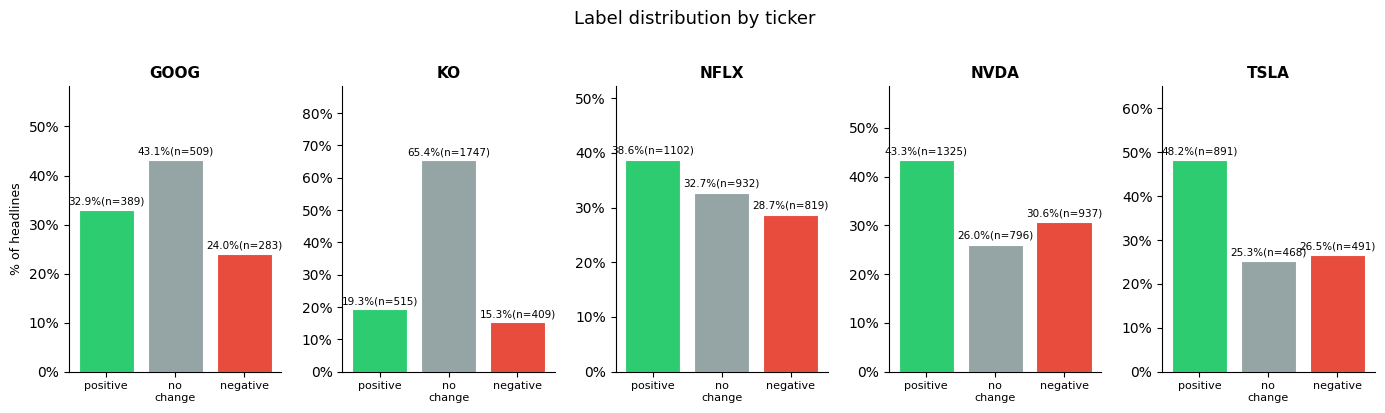

Global label distribution:
label
no_change    4452
positive     4222
negative     2939
Name: count, dtype: int64
--------------------------------------------------
Label distribution by ticker:
label  negative  no_change  positive
stock                               
GOOG        283        509       389
KO          409       1747       515
NFLX        819        932      1102
NVDA        937        796      1325
TSLA        491        468       891


In [ ]:
# Plotting labels distribution for each stock

LABEL_ORDER  = ['positive', 'no_change', 'negative']
LABEL_COLORS = {'positive': '#2ecc71', 'no_change': '#95a5a6', 'negative': '#e74c3c'}
tickers_order = sorted(labeled['stock'].unique())

fig, axes = plt.subplots(1, len(tickers_order), figsize=(14, 4), sharey=False)
fig.suptitle('Label distribution by ticker', fontsize=13, y=1.02)

for ax, ticker in zip(axes, tickers_order):
    sub = labeled[labeled['stock'] == ticker]
    counts = sub['label'].value_counts()
    total  = counts.sum()
    values = [counts.get(l, 0) for l in LABEL_ORDER]
    pcts   = [v / total * 100 for v in values]
    colors = [LABEL_COLORS[l] for l in LABEL_ORDER]

    bars = ax.bar(LABEL_ORDER, pcts, color=colors, edgecolor='white', linewidth=0.8)

    for bar, pct, cnt in zip(bars, pcts, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
                f"{pct:.1f}%(n={cnt})", ha="center", va="bottom", fontsize=7.5)

    ax.set_title(ticker, fontsize=11, fontweight="bold")
    ax.set_ylim(0, max(pcts) * 1.35)
    ax.set_xlabel("")
    ax.set_xticklabels([l.replace("_", "\n") for l in LABEL_ORDER], fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%d%%"))
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel("% of headlines", fontsize=9)
plt.tight_layout()
plt.show()


print("Global label distribution:")
print(labeled['label'].value_counts())
print(50*'-')
print("Label distribution by ticker:")
print(labeled.groupby('stock')['label'].value_counts().unstack(fill_value=0))



## 4. Chronological split & shared training utilities

Train/val/test split by date (past → train, future → val/test), plus the utilities shared by every model in the notebook (metrics, class weights, the weighted-loss trainer and the loss-curve plot).

In [ ]:
# Map string labels to integers so PyTorch can use them as class indices
# negative=0, no_change=1, positive=2

label2id = {"negative": 0, "no_change": 1, "positive": 2}
id2label = {v: k for k, v in label2id.items()}  # reverse map: int → string, used at inference time

# chronological 3-way split (~70% train / ~10% val / ~20% test): train on the past, validate and test on the future (the standard split for
# time-series-derived labels)
sorted_dates = stocks_data["date_key"].sort_values().reset_index(drop=True)
cut_val  = sorted_dates.iloc[int(len(sorted_dates) * 0.70)]   # ~70% of rows before this day
cut_test = sorted_dates.iloc[int(len(sorted_dates) * 0.80)]   # next ~10% val, last ~20% test

train_df = stocks_data[stocks_data["date_key"] < cut_val].copy() # 70% train
val_df   = stocks_data[(stocks_data["date_key"] >= cut_val) & (stocks_data["date_key"] < cut_test)].copy() #10% validation
test_df  = stocks_data[stocks_data["date_key"] >= cut_test].copy() # 20% test

train_df["labels"] = train_df["label"].map(label2id)
val_df["labels"]   = val_df["label"].map(label2id)
test_df["labels"]  = test_df["label"].map(label2id)

print(f"Train: {len(train_df):5d}  (until {cut_val})")
print(f"Val:   {len(val_df):5d}  ({cut_val} → {cut_test})")
print(f"Test:  {len(test_df):5d}  (from {cut_test})")

# check how the label mix shifts over time
for name, d in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"\n{name} label distribution:\n", d["label"].value_counts(normalize=True).round(3).to_string())

Train:  8119  (until 2019-10-02)
Val:    1163  (2019-10-02 → 2020-01-07)
Test:   2331  (from 2020-01-07)

Train label distribution:
 label
no_change    0.427
positive     0.330
negative     0.243

Val label distribution:
 label
positive     0.418
no_change    0.374
negative     0.208

Test label distribution:
 label
positive     0.455
negative     0.310
no_change    0.236


In [ ]:
# Shared evaluation function — used by Stage 1, Model 1, Model 2 and the CV
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
    }

In [ ]:
# Class-weighted loss: the price-derived labels are imbalanced, so the trainer
# weighs each class inversely to its frequency in the TRAIN split.
class_weights = torch.tensor(
    compute_class_weight("balanced", classes=np.array([0, 1, 2]), y=train_df["labels"].values),
    dtype=torch.float,
)
print("Class weights [neg, no_change, pos]:", class_weights.tolist())

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = nn.CrossEntropyLoss(weight=class_weights.to(logits.device))
        loss = loss_fct(logits.view(-1, logits.size(-1)), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

Class weights [neg, no_change, pos]: [1.3702954053878784, 0.7803729176521301, 1.0113353729248047]


In [ ]:
# Train-vs-val loss curves: read the per-epoch history the Trainer already records
def plot_loss_curves(log_history, title, best_metric_key="eval_macro_f1", greater_is_better=True, ax=None):
    train = [(d["epoch"], d["loss"])      for d in log_history if "loss" in d and "eval_loss" not in d and "epoch" in d]
    val   = [(d["epoch"], d["eval_loss"]) for d in log_history if "eval_loss" in d]
    if not train and not val:
        print(f"{title}: no training history (fast path / model loaded from Drive).")
        return
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(8, 4))
    if train:
        ax.plot(*zip(*train), marker="o", markersize=4, label="train loss")
    if val:
        ax.plot(*zip(*val), marker="s", markersize=4, label="val loss")


    scored = [d for d in log_history if best_metric_key in d and "epoch" in d]
    if len(scored) > 1:
        scored = scored[:-1]  # drop the final evaluation (stop epoch, not the restored checkpoint)
    if scored:
        best = (max if greater_is_better else min)(scored, key=lambda d: d[best_metric_key])
        be = best["epoch"]
        metric_name = best_metric_key.replace("eval_", "")
        ax.axvline(be, color="green", ls="--", alpha=0.7,
                   label=f"best ep {be:.0f} ({metric_name}={best[best_metric_key]:.3f})")
        if "eval_loss" in best:
            ax.scatter([be], [best["eval_loss"]], color="green", marker="*", s=180, zorder=5)
            all_epochs = [e for e, _ in (val or train)]
            epoch_range = max(all_epochs) - min(all_epochs) if len(all_epochs) > 1 else 1
            near_right = be > min(all_epochs) + 0.7 * epoch_range
            xoff = -60 if near_right else 8
            ax.annotate(f"ep {be:.0f}", xy=(be, best["eval_loss"]),
                        xytext=(xoff, 6), textcoords="offset points",
                        color="green", fontsize=8, fontweight="bold")

    ax.set_xlabel("epoch", fontsize=8)
    ax.set_ylabel("loss", fontsize=8)
    ax.set_title(title, fontsize=9)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7, frameon=False, loc="best")
    ax.spines[["top", "right"]].set_visible(False)
    if standalone:
        plt.tight_layout()
        plt.show()


# 5. Fast path — load trained models from Google Drive

For the presentation (or any fresh runtime) the trained models are **loaded from Drive instead of retrained**: the cell below restores Model 1 and Model 2 exactly as trained, plus eval-only `trainer` / `trainer_m2`, so every evaluation cell downstream runs unchanged.

Every cell in Sections 6–7 is tagged on its first line:
- `# [training path]` — **skip** in the fast path (the model is loaded here instead).
- `# [fast path]` — runs on the loaded model, no training needed.
- `# [both paths]` — needed either way (e.g. tokenizing the test set, defining `make_model2`).

**Fast path:** run Sections 1–5, then run only the `[fast path]` and `[both paths]` cells and skip every `[training path]` cell. **Full training path:** skip this section (5) and run everything top to bottom.

⚠️ **Note:** Section 7 (cross-validation) **retrains 12 models** and is slow even in the fast path — its results are already reported in Section 8, so it can be skipped for a live run.

In [ ]:
from google.colab import drive



drive.mount("/content/drive")

SAVE_DIR = "/content/drive/MyDrive/gsom_models"
BASE     = "bert-base-uncased"
device   = "cuda" if torch.cuda.is_available() else "cpu"

# Same Stage-1 label config the models were created with. num_labels=3.
s1_id2label = {0: "Bearish", 1: "Bullish", 2: "Neutral"}
s1_label2id = {v: k for k, v in s1_id2label.items()}

bert_tokenizer = AutoTokenizer.from_pretrained(f"{SAVE_DIR}/tokenizer")

def _fresh_base():
    return AutoModelForSequenceClassification.from_pretrained(
        BASE, num_labels=3, id2label=s1_id2label, label2id=s1_label2id,
    )

# Model 1: Stage-1 LoRA (adapter "default") + linear-probe head
m1 = PeftModel.from_pretrained(_fresh_base(), f"{SAVE_DIR}/model1")
m1.classifier.load_state_dict(torch.load(f"{SAVE_DIR}/model1_head.pt", map_location=device))
m1 = m1.to(device).eval()

# Model 2: two adapters ("default" frozen + "stage2") + stage-2 head
m2 = PeftModel.from_pretrained(_fresh_base(), f"{SAVE_DIR}/model2", adapter_name="default")
m2.load_adapter(f"{SAVE_DIR}/model2", adapter_name="stage2")
for module in m2.modules():
    if isinstance(module, ModulesToSaveWrapper):
        module.set_adapter("stage2")
    elif isinstance(module, BaseTunerLayer):
        module.set_adapter(["default", "stage2"])
m2.classifier.load_state_dict(torch.load(f"{SAVE_DIR}/model2_head.pt", map_location=device))
m2 = m2.to(device).eval()

# Aliases + eval-only Trainers, so every downstream cell works without retraining
bert_model    = m1
bert_model_m2 = m2
data_collator = DataCollatorWithPadding(tokenizer=bert_tokenizer)

def _eval_trainer(model, out_dir):
    return Trainer(
        model=model,
        args=TrainingArguments(output_dir=out_dir, per_device_eval_batch_size=64, report_to="none"),
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

trainer    = _eval_trainer(m1, "eval_m1")
trainer_m2 = _eval_trainer(m2, "eval_m2")

print("Model 1 and Model 2 loaded from", SAVE_DIR)

# 6. Train the Model

Fine-tune **`bert-base-uncased`** with **LoRA** (Low-Rank Adaptation, via HuggingFace `peft`).

LoRA keeps BERT's pretrained weights frozen and trains only small low-rank matrices inserted into the attention layers, plus a fresh 3-class classification head.

## LoRA on Twitter Financial News Sentiment

Before fine-tuning on our dataset, we first train BERT+LoRA on **Twitter Financial News Sentiment** ~11.9k finance tweets with 3 classes: 0=Bearish, 1=Bullish, 2=Neutral
This gives the backbone solid financial-sentiment representations before we transfer to training on our dataset.



In [ ]:
# [training path] — load Stage-1 Twitter data; skip in fast path 
# Twitter Financial News Sentiment
raw = load_dataset("zeroshot/twitter-financial-news-sentiment")

# Dataset has "train" and "validation" splits already
twitter_train = raw["train"]
twitter_val   = raw["validation"]

print(f"\nTrain: {len(twitter_train)} | Val: {len(twitter_val)}")
print("label counts (train):", Counter(twitter_train["label"]))
print("label counts (val):", Counter(twitter_val["label"]))


Train: 9543 | Val: 2388
label counts (train): Counter({2: 6178, 1: 1923, 0: 1442})
label counts (val): Counter({2: 1566, 1: 475, 0: 347})


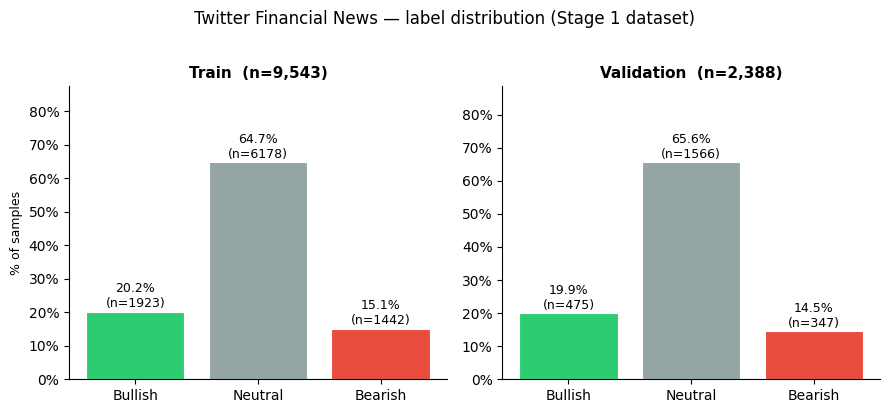

In [ ]:
# [training path] — Stage-1 EDA plot; skip in fast path
# Plotting labels distribution for each tweet
S1_LABEL_MAP    = {0: 'Bearish', 1: 'Bullish', 2: 'Neutral'}
S1_LABEL_ORDER  = ['Bullish', 'Neutral', 'Bearish']
S1_LABEL_COLORS = {'Bullish': '#2ecc71', 'Neutral': '#95a5a6', 'Bearish': '#e74c3c'}

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
fig.suptitle('Twitter Financial News — label distribution (Stage 1 dataset)', fontsize=12, y=1.02)

for ax, (split_name, split_ds) in zip(axes, [('Train', twitter_train), ('Validation', twitter_val)]):
    raw_counts = Counter(split_ds['label'])
    counts = {S1_LABEL_MAP[k]: v for k, v in raw_counts.items()}
    total  = sum(counts.values())
    values = [counts.get(l, 0) for l in S1_LABEL_ORDER]
    pcts   = [v / total * 100 for v in values]
    colors = [S1_LABEL_COLORS[l] for l in S1_LABEL_ORDER]

    bars = ax.bar(S1_LABEL_ORDER, pcts, color=colors, edgecolor='white', linewidth=0.8)
    for bar, pct, cnt in zip(bars, pcts, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{pct:.1f}%\n(n={cnt})", ha='center', va='bottom', fontsize=9)

    ax.set_title(f"{split_name}  (n={total:,})", fontsize=11, fontweight='bold')
    ax.set_ylim(0, max(pcts) * 1.35)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%d%%'))
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel('% of samples', fontsize=9)
plt.tight_layout()
plt.show()


In [ ]:
# [training path] — build base BERT for Stage 1; skip in fast path
# downloading BERT base model and its tokenizer
BASE = "bert-base-uncased"

bert_tokenizer = AutoTokenizer.from_pretrained(BASE)

# Stage 1 label mapping
s1_id2label = {0: "Bearish", 1: "Bullish", 2: "Neutral"}
s1_label2id = {v: k for k, v in s1_id2label.items()}

bert_model = AutoModelForSequenceClassification.from_pretrained(
    BASE,
    num_labels=3,
    id2label=s1_id2label,
    label2id=s1_label2id,
)


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# [training path] — Stage-1 LoRA config; skip in fast path
# LoRA configuration

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=16,                                           # rank -> it represents the bottleneck dimension i.e. how much the adapter can learn (trainable parameters)
    lora_alpha=32,                                  # alpha (alpha/r) -> scaling factor controlling adapter strength i.e. how much the adapter influences the frozen weights
                                                    # we chose a fixed adapter of alpha/r = 2.0
    lora_dropout=0.1,
    target_modules=["query", "key", "value"],
)
bert_model = get_peft_model(bert_model, lora_config)
bert_model.print_trainable_parameters()

trainable params: 887,043 || all params: 110,371,590 || trainable%: 0.8037


In [ ]:
# [training path] — tokenize Stage-1 data; skip in fast path
# Twitter Financial News uses column "text"; stocks_data uses "title"

def tokenize_twitter(batch):
    return bert_tokenizer(batch["text"], truncation=True, max_length=64)


# Create a test split from the existing twitter_val dataset (from raw["validation"])
twitter_val_split = twitter_val.train_test_split(test_size=0.2, seed=RANDOM_SEED)

# Reassign twitter_val and define twitter_test based on this split
# (Note: 'twitter_val' here will overwrite the 'twitter_val' from raw["validation"])
twitter_val  = twitter_val_split["train"]
twitter_test = twitter_val_split["test"]


# Then tokenize ALL three splits
# 'twitter_train' refers to the original 'raw["train"]'
twitter_train = twitter_train.map(tokenize_twitter, batched=True)
twitter_val   = twitter_val.map(tokenize_twitter, batched=True)
twitter_test  = twitter_test.map(tokenize_twitter, batched=True)

twitter_data_collator = DataCollatorWithPadding(tokenizer=bert_tokenizer)

Map:   0%|          | 0/9543 [00:00<?, ? examples/s]

Map:   0%|          | 0/1910 [00:00<?, ? examples/s]

Map:   0%|          | 0/478 [00:00<?, ? examples/s]

In [ ]:
# [training path] — train Stage-1 LoRA; skip in fast path (loaded in §5)
# Stage 1 training: LoRA on the Twitter financial-sentiment dataset
stage1_args = TrainingArguments(
    output_dir="stage1_out",
    num_train_epochs=30,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-4,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,        # restore best checkpoint by macro_f1
    metric_for_best_model="macro_f1",   # use f1 for unbalanced labels distribution
    greater_is_better=True,
    fp16=True,
    report_to="none",
)

stage1_trainer = Trainer(
    model=bert_model,
    args=stage1_args,
    train_dataset=twitter_train,
    eval_dataset=twitter_val,
    data_collator=twitter_data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)],
)

stage1_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,No log,0.571322,0.884817,0.848196
2,0.070595,0.621849,0.884817,0.847336
3,0.070595,0.668156,0.883246,0.846960
4,0.025669,0.689801,0.882199,0.845528
5,0.025669,0.695030,0.884293,0.847360
6,0.025642,0.723453,0.880628,0.843069


TrainOutput(global_step=1794, training_loss=0.03697159829878621, metrics={'train_runtime': 91.8265, 'train_samples_per_second': 3117.728, 'train_steps_per_second': 97.684, 'total_flos': 1621561364329896.0, 'train_loss': 0.03697159829878621, 'epoch': 6.0})

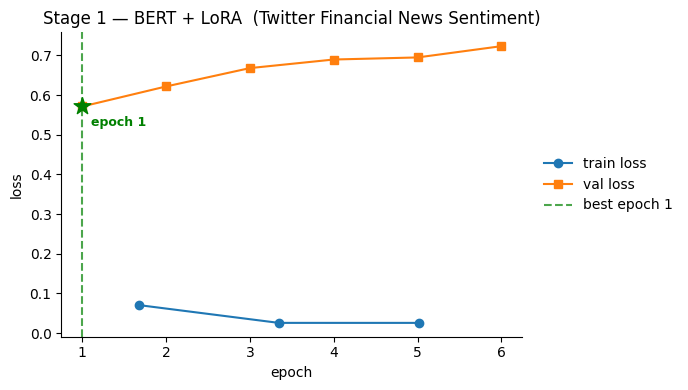

In [ ]:
# [training path] — Stage-1 loss curve; skip in fast path
plot_loss_curves(stage1_trainer.state.log_history, "Stage 1 — BERT + LoRA  (Twitter Financial News Sentiment)")

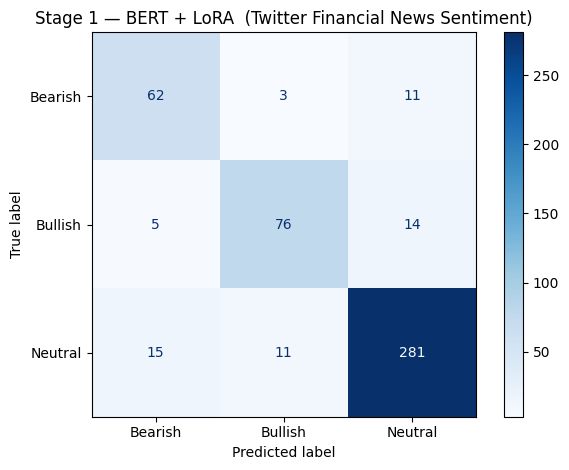

Accuracy: 0.877
Macro F1: 0.841
              precision    recall  f1-score   support

     Bearish      0.756     0.816     0.785        76
     Bullish      0.844     0.800     0.822        95
     Neutral      0.918     0.915     0.917       307

    accuracy                          0.877       478
   macro avg      0.840     0.844     0.841       478
weighted avg      0.878     0.877     0.877       478



In [ ]:
# [training path] — Stage-1 test metrics; skip in fast path
# Stage 1 confusion matrix — Twitter Financial News Sentiment (test split)

s1_preds = stage1_trainer.predict(twitter_test)
s1_pred_ids  = np.argmax(s1_preds.predictions, axis=-1)
s1_true_ids  = s1_preds.label_ids

S1_LABELS    = ['Bearish', 'Bullish', 'Neutral']
S1_LABEL_IDS = [0, 1, 2]

cm_s1 = confusion_matrix(s1_true_ids, s1_pred_ids, labels=S1_LABEL_IDS)
disp  = ConfusionMatrixDisplay(cm_s1, display_labels=S1_LABELS)
disp.plot(cmap='Blues', values_format='d')
plt.title('Stage 1 — BERT + LoRA  (Twitter Financial News Sentiment)')
plt.tight_layout()
plt.show()

# Calculate and print accuracy and F1 score
s1_accuracy = accuracy_score(s1_true_ids, s1_pred_ids)
s1_macro_f1 = f1_score(s1_true_ids, s1_pred_ids, average='macro')

print(f"Accuracy: {s1_accuracy:.3f}")
print(f"Macro F1: {s1_macro_f1:.3f}")
print(classification_report(s1_true_ids, s1_pred_ids, target_names=S1_LABELS, digits=3))

In [ ]:
# [training path] — freeze backbone + reset head; skip in fast path
# Freeze everything: BERT body + Stage-1 LoRA weights are now fixed feature extractors
for param in bert_model.parameters():
    param.requires_grad = False

# Re-initialize only the classification head for Stage 2 trains
for name, param in bert_model.named_parameters():
    if "classifier" in name:
        if param.dim() > 1:
            torch.nn.init.normal_(param, mean=0.0, std=0.02)
        else:
            torch.nn.init.zeros_(param)
        param.requires_grad = True

bert_model.print_trainable_parameters()


trainable params: 4,614 || all params: 110,371,590 || trainable%: 0.0042


In [ ]:
# [both paths] — needed in the fast path too: builds train_ds/val_ds/test_ds for evaluation
# Tokenize the dataset

def tokenize(batch):
    return bert_tokenizer(batch["title"], truncation=True, max_length=64)

train_ds = Dataset.from_pandas(train_df[["title", "labels"]], preserve_index=False).map(tokenize, batched=True)
val_ds   = Dataset.from_pandas(val_df[["title", "labels"]],   preserve_index=False).map(tokenize, batched=True)
test_ds  = Dataset.from_pandas(test_df[["title", "labels"]],  preserve_index=False).map(tokenize, batched=True)

# Dynamic padding per batch (pads to the longest sequence in the batch, not the dataset).

data_collator = DataCollatorWithPadding(tokenizer=bert_tokenizer)

Map:   0%|          | 0/8119 [00:00<?, ? examples/s]

Map:   0%|          | 0/1163 [00:00<?, ? examples/s]

Map:   0%|          | 0/2331 [00:00<?, ? examples/s]

## Model 1 — Linear probe on price-derived labels

The BERT + Stage-1 LoRA are now **frozen**. Only the classification head (Linear 768→3)
is trainable. We fit it on `stocks_data` (our news dataset) — this is a
**linear probe**: it tests whether the frozen Stage-1 features are already useful for the price-movement task without further adaptation of the representation itself.


In [ ]:
# [training path] — train Model 1 head; skip in fast path (loaded in §5)
# Training the feed forward classification head to understand whether the LoRA feature extraction is helpful for our task

training_args = TrainingArguments(
    output_dir="bert_lora_out",
    num_train_epochs=30,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-4,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    fp16=True,
    report_to="none",
)

trainer = WeightedTrainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,               # val set drives early stopping and model selection
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)], # early stopping after 5 epochs w/o any improvements
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.083192,1.092546,0.334480,0.280569
2,1.078447,1.068787,0.428203,0.409087
3,1.081727,1.087109,0.426483,0.398100
4,1.084420,1.085212,0.423904,0.400783
5,1.081538,1.075431,0.435082,0.398851
6,1.077030,1.076838,0.345658,0.299026
7,1.078956,1.067994,0.441101,0.412902
8,1.078038,1.079648,0.354256,0.349909
9,1.080462,1.076524,0.357696,0.338606
10,1.076702,1.066955,0.436801,0.403422


TrainOutput(global_step=3048, training_loss=1.0790935926862901, metrics={'train_runtime': 148.4185, 'train_samples_per_second': 1641.103, 'train_steps_per_second': 51.341, 'total_flos': 2594048646016332.0, 'train_loss': 1.0790935926862901, 'epoch': 12.0})

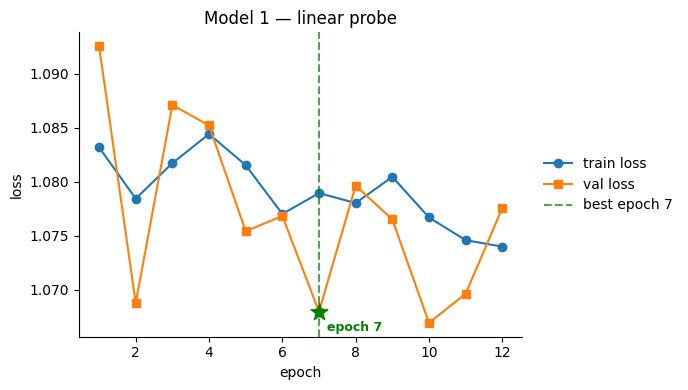

In [ ]:
# [training path] — Model 1 loss curve; skip in fast path (no curve when loaded)
# Train-vs-val loss curve
plot_loss_curves(trainer.state.log_history, "Model 1 — linear probe")

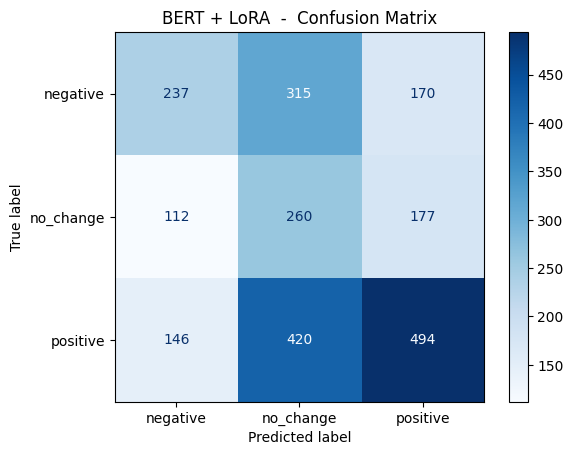

Accuracy : 0.425
Macro F1 : 0.415

              precision    recall  f1-score   support

    negative      0.479     0.328     0.389       722
   no_change      0.261     0.474     0.337       549
    positive      0.587     0.466     0.520      1060

    accuracy                          0.425      2331
   macro avg      0.442     0.423     0.415      2331
weighted avg      0.477     0.425     0.436      2331



In [ ]:
# [fast path] — Model 1 eval via the §5 trainer; no training needed
# Predict on the held-out test set
pred_logits = trainer.predict(test_ds).predictions
pred_ids = np.argmax(pred_logits, axis=-1)
test_df["model1_pred"] = [id2label[i] for i in pred_ids]
y_true = test_df["label"]
y_pred = test_df["model1_pred"]
LABELS = ["negative", "no_change", "positive"]

# Plot the confusion matrix

cm = confusion_matrix(y_true, y_pred, labels=LABELS)
disp = ConfusionMatrixDisplay(cm, display_labels=LABELS)
disp.plot(cmap="Blues", values_format="d")
plt.title("BERT + LoRA  -  Confusion Matrix")
plt.show()

# print accuracy and f1 score
bert_acc      = accuracy_score(y_true, y_pred)
bert_macro_f1 = f1_score(y_true, y_pred, average="macro", labels=LABELS)
print(f"Accuracy : {bert_acc:.3f}")
print(f"Macro F1 : {bert_macro_f1:.3f}")
print()

print(classification_report(y_true, y_pred, labels=LABELS, digits=3))



In [ ]:
# [fast path] — per-ticker Model 1 scores (uses test_df from the eval above)
# Analysis of per-ticker macro-F1 on the held-out test set

bert_per_ticker = (
    test_df.groupby("stock")
    .apply(lambda g: f1_score(g["label"], g["model1_pred"], average="macro", labels=LABELS))
    .rename("f1_score")
    .sort_values(ascending=False)
)
print("BERT + LoRA F1-score by ticker (test set):")
print(bert_per_ticker.to_string())

# overview of 10 sample test rows
test_df[["title", "stock", "label", "model1_pred"]].sample(10)

BERT + LoRA F1-score by ticker (test set):
stock
NVDA    0.462149
KO      0.448098
TSLA    0.415138
NFLX    0.383163
GOOG    0.375382


,title,stock,label,model1_pred
3846,Shares of several consumer goods companies are...,KO,positive,positive
10703,"'Exponential Growth': Tesla's Scale, Ambition ...",TSLA,positive,negative
10939,Mattel Shares Unaffected Following 'Tesla part...,TSLA,no_change,positive
6437,"Disney Had The Content, But The Media Giant Is...",NFLX,no_change,positive
10725,"Position Scrimmage: Coronavirus, End-Of-Month ...",TSLA,positive,negative
11243,Tesla to Furlough Hourly Workers at U.S. Car P...,TSLA,no_change,negative
10890,Tesla shares are trading higher after Morgan S...,TSLA,positive,positive
11314,'All-Electric Lexus Goes On Sale In China This...,TSLA,positive,positive
9675,NVIDIA shares are trading higher potentially o...,NVDA,positive,positive
11320,'Tesla Is Working On Pay-As-You-Go Subscriptio...,TSLA,negative,positive


## Model 2 — 2 stacked LoRA layers + Linear Probe

BERT  and **Stage-1 LoRA** stays **frozen** and we keep it as a **second, still-live adapter** and stack a new **Stage-2 LoRA** on top of it. Both adapters are active, so their low-rank deltas sum in the forward pass: `logits = BERT_base(x) + Stage1_LoRA(x) + Stage2_LoRA(x)`, with only the Stage-2 LoRA and a re-initialized classification head trainable. This lets the model adapt its representations to our price-derived labels beyond what the linear probe on frozen Stage-1 features achieved.


In [ ]:
# [both paths] — defines make_model2()/stage1_source(); used by the fast path and the CV
# Model 2 construction, defined ONCE — used both for the main Model 2 (r=16) below
# and by the CV grid at arbitrary Stage-2 ranks.


def stage1_source():
    """BERT + the TRAINED Stage-1 LoRA (PEFT adapter "default"):
    `m1` if reloaded from Drive, else the live `bert_model` from the Stage-1 cells."""
    for candidate in ("m1", "bert_model"):
        src = globals().get(candidate)
        if isinstance(src, PeftModel) and "default" in src.peft_config:
            return src
    raise RuntimeError("Trained Stage-1 LoRA not found: run the Stage-1 cells or the load-from-Drive cell first.")


def make_model2(rank):
    """Frozen BERT + frozen Stage-1 LoRA ("default") + fresh trainable Stage-2 LoRA (r=rank) + fresh head."""
    model = copy.deepcopy(stage1_source())
    cfg = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=rank,
        lora_alpha=2 * rank,                        # keep alpha/r = 2, same ratio as Stage 1
        lora_dropout=0.1,
        target_modules=["query", "key", "value"],
    )
    model.add_adapter("stage2", cfg)

    # Activate the adapters per layer type. We CANNOT call set_adapter(["default","stage2"])
    # globally: task_type=SEQ_CLS wraps the classifier in a ModulesToSaveWrapper, which keeps a
    # SEPARATE FULL head per adapter and rejects activating two at once. So:
    #   • LoRA attention layers  -> activate BOTH adapters so their low-rank deltas SUM.
    #   • classifier wrapper     -> activate ONLY "stage2" (the fresh, trainable head).
    for module in model.modules():
        if isinstance(module, ModulesToSaveWrapper):
            module.set_adapter("stage2")
        elif isinstance(module, BaseTunerLayer):
            module.set_adapter(["default", "stage2"])

    # set_adapter() re-enables requires_grad on all active adapters, so the Stage-1 freeze comes AFTER
    for name, param in model.named_parameters():
        if "lora_" in name:
            param.requires_grad = ("stage2" in name)   # train stage2 LoRA, freeze default LoRA

    # Fresh, trainable stage-2 classification head (the inactive "default" head never runs)
    for name, param in model.named_parameters():
        if "classifier" in name and "stage2" in name:
            if param.dim() > 1:
                torch.nn.init.normal_(param, mean=0.0, std=0.02)
            else:
                torch.nn.init.zeros_(param)
            param.requires_grad = True

    trainable = [n for n, p in model.named_parameters() if p.requires_grad]
    assert all(("stage2" in n) or ("classifier" in n) for n in trainable), trainable
    assert any("lora_" in n and "stage2" in n for n in trainable), "Stage-2 LoRA must be trainable"
    return model

In [ ]:
# [training path] — build Model 2 (r=16); skip in fast path (loaded in §5)
# Model 2 — two stacked LoRA adapters
bert_model_m2 = make_model2(16)
bert_model_m2.print_trainable_parameters()

trainable params: 887,043 || all params: 111,258,633 || trainable%: 0.7973


In [ ]:
# [training path] — train Model 2; skip in fast path (loaded in §5)
# Same split, tokenized datasets, class weights and weighted-loss Trainer as Model 1

stage3_args = TrainingArguments(
    output_dir="bert_lora_m2_out",
    num_train_epochs=30,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-4,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,         # keep the best epoch by val macro_f1
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    fp16=True,
    report_to="none",
)

trainer_m2 = WeightedTrainer(
    model=bert_model_m2,
    args=stage3_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,         # dynamic padding — same as Model 1
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)], # keep the 5 epochs earlystopping
)

trainer_m2.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.083783,1.088176,0.337919,0.278580
2,1.058206,1.079222,0.438521,0.400418
3,1.018090,1.075532,0.439381,0.422737
4,0.984911,1.110796,0.434222,0.422827
5,0.955674,1.123815,0.428203,0.413818
6,0.922345,1.147600,0.407567,0.387212
7,0.886619,1.177541,0.418745,0.406675
8,0.848891,1.231631,0.418745,0.396687
9,0.817949,1.254673,0.415305,0.410678


TrainOutput(global_step=2286, training_loss=0.9529407731504265, metrics={'train_runtime': 351.5133, 'train_samples_per_second': 692.918, 'train_steps_per_second': 21.678, 'total_flos': 1965365917159320.0, 'train_loss': 0.9529407731504265, 'epoch': 9.0})

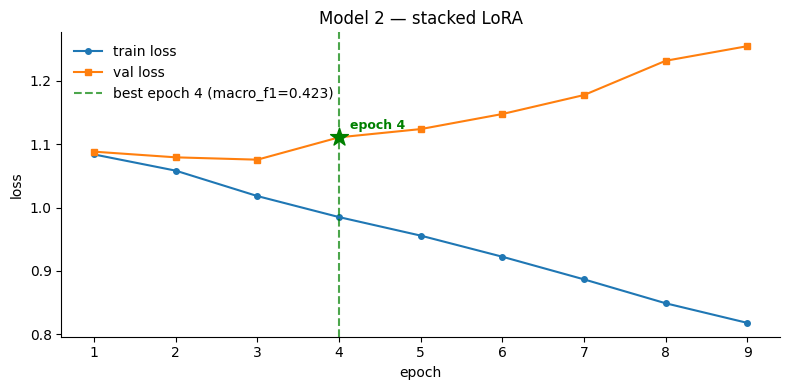

In [ ]:
# [training path] — Model 2 loss curve; skip in fast path (no curve when loaded)
# Train-vs-val loss curve
plot_loss_curves(trainer_m2.state.log_history, "Model 2 — stacked LoRA")

Accuracy : 0.409
Macro F1 : 0.397

              precision    recall  f1-score   support

    negative      0.385     0.435     0.408       722
   no_change      0.266     0.337     0.297       549
    positive      0.555     0.429     0.484      1060

    accuracy                          0.409      2331
   macro avg      0.402     0.400     0.397      2331
weighted avg      0.434     0.409     0.417      2331



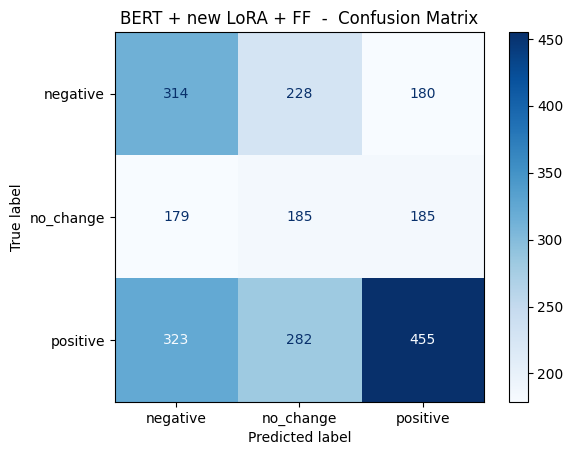

In [ ]:
# [fast path] — Model 2 eval via the §5 trainer_m2; no training needed
# Same model analysis as Model 1

pred_logits_m2 = trainer_m2.predict(test_ds).predictions
pred_ids_m2 = np.argmax(pred_logits_m2, axis=-1)
test_df["model2_pred"] = [id2label[i] for i in pred_ids_m2]


y_true = test_df["label"]
y_pred_m2 = test_df["model2_pred"]
LABELS = ["negative", "no_change", "positive"]

m2_acc      = accuracy_score(y_true, y_pred_m2)
m2_macro_f1 = f1_score(y_true, y_pred_m2, average="macro", labels=LABELS)
print(f"Accuracy : {m2_acc:.3f}")
print(f"Macro F1 : {m2_macro_f1:.3f}")
print()

print(classification_report(y_true, y_pred_m2, labels=LABELS, digits=3))

cm = confusion_matrix(y_true, y_pred_m2, labels=LABELS)
disp = ConfusionMatrixDisplay(cm, display_labels=LABELS)
disp.plot(cmap="Blues", values_format="d")
plt.title("BERT + new LoRA + FF  -  Confusion Matrix")
plt.show()

In [ ]:
# [fast path] — per-ticker Model 2 scores (uses test_df from the eval above)
# Same per-ticker analysis

m2_per_ticker = (
    test_df.groupby("stock")
    .apply(lambda g: f1_score(g["label"], g["model2_pred"], average="macro", labels=LABELS))
    .rename("f1_score")
    .sort_values(ascending=False)
)
print("BERT + new LoRA + FF  F1-score by ticker (test set):")
print(m2_per_ticker.to_string())

test_df[["title", "stock", "label", "model1_pred", "model2_pred"]].head(10)

BERT + new LoRA + FF  F1-score by ticker (test set):
stock
KO      0.423423
TSLA    0.391796
NVDA    0.388684
NFLX    0.382180
GOOG    0.340836


,title,stock,label,model1_pred,model2_pred
747,'Sonos sues Google for allegedly swiping speak...,GOOG,no_change,negative,negative
748,A Decent Outlook For This Facebook-Heavy ETF,GOOG,no_change,positive,no_change
749,Stocks That Hit 52-Week Highs On Thursday,GOOG,positive,positive,positive
750,Bernstein Initiates Coverage On Facebook And G...,GOOG,positive,positive,positive
751,"Spotify, YouTube, Other Streaming Platforms Ex...",GOOG,no_change,positive,positive
752,Stocks That Hit 52-Week Highs On Friday,GOOG,no_change,positive,positive
753,Evercore ISI Group Maintains Outperform on Alp...,GOOG,no_change,positive,positive
754,Microsoft CEO Criticizes India's Exclusionary ...,GOOG,no_change,no_change,no_change
755,'Google is buying an Irish retail search start...,GOOG,no_change,positive,positive
756,Cramer Weighs In On Whether Alphabet Is Worth ...,GOOG,no_change,no_change,positive


## Dummy Classifier (baseline performance)

For evaluating the performance of our fine-tuned models, it's crucial to establish a baseline using simple, non-predictive dummy classifiers.
This section calculates the accuracy and Macro-F1 scores for 'most_frequent' and 'stratified' dummy classifiers. These baselines provide a lower bound for expected performance, helping us understand if our more complex models (Model 1 and Model 2) are truly learning meaningful patterns beyond what could be achieved by chance or by simply predicting the majority class.

In [ ]:
# [fast path] — DummyClassifier baselines; no model needed, runs in either path

LABELS = ["negative", "no_change", "positive"]
y_train_lbl = train_df["label"]
y_test_lbl  = test_df["label"]

# DummyClassifier ignores X, but the API needs a feature matrix of the right length

X_tr = np.zeros((len(y_train_lbl), 1))
X_te = np.zeros((len(y_test_lbl), 1))

# Func to predic majority and stratified DummyClassifier

def dummy_eval(strategy, seed=None):
    clf = DummyClassifier(strategy=strategy, random_state=seed).fit(X_tr, y_train_lbl)
    yp = clf.predict(X_te)
    return (accuracy_score(y_test_lbl, yp),
            f1_score(y_test_lbl, yp, average="macro", labels=LABELS, zero_division=0))

baseline_rows = {}

# Majority class: always predicts the most frequent train label (deterministic, no seed)

acc, mf1 = dummy_eval("most_frequent")
baseline_rows["most_frequent"] = (acc, mf1)
print(f"{'most_frequent':14s} acc={acc:.3f}  macroF1={mf1:.3f}")

# Stratified random: samples labels from the train distribution on the mean of 50 different seeds

accs, f1s = zip(*[dummy_eval("stratified", seed=s) for s in range(50)])
baseline_rows["stratified"] = (float(np.mean(accs)), float(np.mean(f1s)))
print(f"{'stratified':14s} acc={np.mean(accs):.3f} +/- {np.std(accs):.3f}  "
      f"macroF1={np.mean(f1s):.3f} +/- {np.std(f1s):.3f}")


most_frequent  acc=0.236  macroF1=0.127
stratified     acc=0.326 +/- 0.011  macroF1=0.320 +/- 0.010


In [ ]:
# [fast path] — comparison table from metrics above (guarded with `in globals()`)
# Dummy vs Model 1 and Model 2

rows = [
    ("Majority class (most_frequent)", *baseline_rows["most_frequent"]),
    ("Stratified random (50 seeds)",   *baseline_rows["stratified"]),
]

if "bert_acc" in globals():
    rows.append(("Model 1 - linear probe", bert_acc, bert_macro_f1))
if "m2_acc" in globals():
    rows.append(("Model 2 - new LoRA + FF", m2_acc, m2_macro_f1))


results = pd.DataFrame(rows, columns=["Model", "Accuracy", "Macro-F1"]).set_index("Model")
print(results.round(3).to_string())

# Gap of each model over the strongest chance macro-F1 floor.
chance_f1 = max(baseline_rows["stratified"][1], baseline_rows["most_frequent"][1])
print(f"\nStrongest chance macro-F1 floor: {chance_f1:.3f}")
for name, _, mf1 in rows:
    if name.startswith("Model"):
        print(f"  {name:30s} macro-F1 {mf1:.3f}  ->  {(mf1 - chance_f1)/chance_f1*100:+.1f}% vs chance")

                                Accuracy  Macro-F1
Model                                             
Majority class (most_frequent)     0.236     0.127
Stratified random (50 seeds)       0.326     0.320
Model 1 - linear probe             0.425     0.415
Model 2 - new LoRA + FF            0.409     0.397

Strongest chance macro-F1 floor: 0.320
  Model 1 - linear probe         macro-F1 0.415  ->  +29.7% vs chance
  Model 2 - new LoRA + FF        macro-F1 0.397  ->  +23.9% vs chance


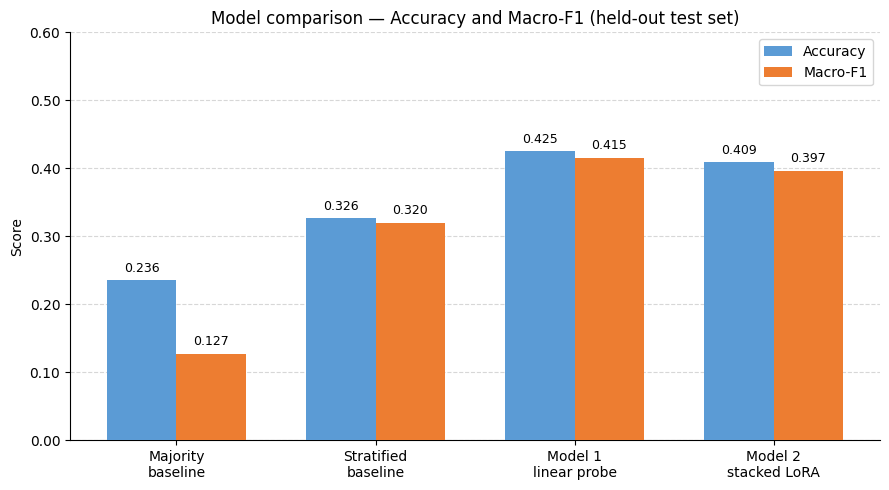

In [ ]:
# [fast path] — comparison bar chart from the table above
# Model comparison bar chart

short_names = [
    'Majority\nbaseline',
    'Stratified\nbaseline',
    'Model 1\nlinear probe',
    'Model 2\nstacked LoRA',
]

acc_vals = results['Accuracy'].values
f1_vals  = results['Macro-F1'].values
x        = np.arange(len(short_names))
width    = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars_acc = ax.bar(x - width/2, acc_vals, width, label='Accuracy', color='#5b9bd5', zorder=3)
bars_f1  = ax.bar(x + width/2, f1_vals,  width, label='Macro-F1', color='#ed7d31', zorder=3)

# value labels on top of each bar
for bar in bars_acc:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars_f1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(short_names, fontsize=10)
ax.set_ylim(0, 0.6)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax.set_ylabel('Score')
ax.set_title('Model comparison — Accuracy and Macro-F1 (held-out test set)')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

# 7. Cross-validation — Stage-2 LoRA rank

Lastly, we run a `k=3` expanding-window time-fold cross-validation × 4 Model-2 ranks (12 training runs).

**Purpose:** Model 2 was trained with r=16, and this section serves two roles:

1. **Rank sensitivity analysis**: checks whether r=16 is a robust choice, or whether a
   smaller/larger rank would have generalised better across different time windows.

2. **Stability / overfitting check**: the final cell compares Model 2's single-split
   test macro-F1 against the CV mean ± std for r=16. If the test score falls *inside*
   the band, the result is consistent across folds and not an artifact of this
   particular train/test split.

In [ ]:
# [both paths] — CV helper definitions only (safe to run; no training here)
# CV helpers: train/score one fold of the Stage-2 rank grid

RANK_GRID = [8, 16, 32, 64]   # Stage-2 LoRA rank and alpha is locked at 2*r


def _to_ds(df):
    return Dataset.from_pandas(df[["title", "labels"]], preserve_index=False).map(tokenize, batched=True)


def run_cv_fold(fold_train_df, fold_val_df, fold_test_df, rank, tag, max_epochs=30, patience=5):
    """Train a fresh Model 2 (Stage-2 rank=rank) and score it on the held-out test fold.

    Three splits per fold, so there is NO leakage into the reported score:
      • fold_train_df → train the Stage-2 LoRA + head
      • fold_val_df   → early stopping + best-checkpoint selection (model is never SCORED on it)
      • fold_test_df  → the held-out fold, touched only ONCE for the final score
    Returns (macro-F1, accuracy) on fold_test_df.
    """
    global class_weights
    set_seed(RANDOM_SEED)

    class_weights = torch.tensor(
        compute_class_weight("balanced", classes=np.array([0, 1, 2]),
                             y=fold_train_df["labels"].values),
        dtype=torch.float,
    )
    tr_ds       = _to_ds(fold_train_df)
    val_ds_fold = _to_ds(fold_val_df)
    te_ds       = _to_ds(fold_test_df)

    model = make_model2(rank)
    args = TrainingArguments(
        output_dir=f"cv_out/{tag}",
        num_train_epochs=max_epochs,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=64,
        learning_rate=2e-4,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        logging_strategy="epoch",  # log train loss each epoch so plot_loss_curves can draw it
        load_best_model_at_end=True,           # best epoch is chosen on the VALIDATION split
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        fp16=True,
        report_to="none",
        disable_tqdm=False,
    )
    cv_trainer = WeightedTrainer(
        model=model,
        args=args,
        train_dataset=tr_ds,
        eval_dataset=val_ds_fold,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=patience)],
    )
    cv_trainer.train()
    metrics = cv_trainer.evaluate(te_ds)       # held-out test fold, scored once
    f1, acc = metrics["eval_macro_f1"], metrics["eval_accuracy"]
    history = list(cv_trainer.state.log_history)  # train+val loss per epoch (for plot_loss_curves)

    # free GPU memory and checkpoint disk before the next run
    del cv_trainer, model
    gc.collect()
    torch.cuda.empty_cache()
    shutil.rmtree(f"cv_out/{tag}", ignore_errors=True)
    return f1, acc, history

In [ ]:
# [training path] — retrains 12 models (slow)
# CV grid

cv_df = pd.concat([train_df, val_df]).sort_values("date_key").reset_index(drop=True)
unique_dates = np.sort(cv_df["date_key"].unique())
print(f"CV pool: {len(cv_df)} headlines over {len(unique_dates)} trading days "
      f"({unique_dates[0]} → {unique_dates[-1]}) — test set NOT included")

cv_records = []
cv_histories = {}  # (fold, rank) -> training log_history, used by the loss-curve cell below

for fold, (tr_idx, te_idx) in enumerate(TimeSeriesSplit(n_splits=3).split(unique_dates), start=1):
    train_dates, test_dates = unique_dates[tr_idx], unique_dates[te_idx]


    val_cut    = train_dates[int(len(train_dates) * 0.85)]
    fit_dates  = train_dates[train_dates < val_cut]
    val_dates  = train_dates[train_dates >= val_cut]

    fold_train = cv_df[cv_df["date_key"].isin(fit_dates)]
    fold_val   = cv_df[cv_df["date_key"].isin(val_dates)]
    fold_test  = cv_df[cv_df["date_key"].isin(test_dates)]

    print(f"\n── Fold {fold}: train {len(fold_train)} ({fit_dates[0]} → {fit_dates[-1]}) | "
          f"val {len(fold_val)} ({val_dates[0]} → {val_dates[-1]}) | "
          f"test {len(fold_test)} ({test_dates[0]} → {test_dates[-1]})")

    for rank in RANK_GRID:
        f1, acc, hist = run_cv_fold(fold_train, fold_val, fold_test, rank, tag=f"f{fold}_r{rank}")
        cv_records.append({"fold": fold, "rank": rank, "macro_f1": f1, "accuracy": acc})
        cv_histories[(fold, rank)] = hist
        print(f"   r={rank:<3d} (alpha={2*rank:<3d}) → held-out test macro-F1 {f1:.3f} (acc {acc:.3f})")

# restore the global class weights of the original train split (used by earlier cells)
class_weights = torch.tensor(
    compute_class_weight("balanced", classes=np.array([0, 1, 2]), y=train_df["labels"].values),
    dtype=torch.float,
)

CV pool: 9282 headlines over 1920 trading days (2009-08-10 → 2020-01-06) — test set NOT included

── Fold 1: train 1017 (2009-08-10 → 2012-07-10) | val 174 (2012-07-11 → 2012-11-30) | test 1260 (2012-12-03 → 2015-11-17)


Map:   0%|          | 0/1017 [00:00<?, ? examples/s]

Map:   0%|          | 0/174 [00:00<?, ? examples/s]

Map:   0%|          | 0/1260 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.134980,1.117149,0.402299,0.348944
2,1.106388,1.142371,0.264368,0.256830
3,1.092058,1.131316,0.362069,0.353094
4,1.083280,1.130923,0.367816,0.347708
5,1.057362,1.146142,0.379310,0.351097
6,1.028376,1.169281,0.373563,0.347327
7,1.014473,1.166817,0.408046,0.372170
8,0.990662,1.208117,0.379310,0.340426
9,0.978625,1.208251,0.367816,0.355305
10,0.925888,1.252437,0.379310,0.361574


...

Map:   0%|          | 0/1305 [00:00<?, ? examples/s]

Map:   0%|          | 0/4271 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.088503,1.100503,0.400000,0.375576
2,1.043163,1.114641,0.450575,0.393851
3,0.993914,1.095354,0.416858,0.405721
4,0.929547,1.157523,0.408429,0.397407
5,0.851472,1.232830,0.408429,0.392831
6,0.759897,1.338880,0.439847,0.415974
7,0.669451,1.364520,0.423755,0.395093
8,0.590339,1.589018,0.417625,0.391925
9,0.525237,1.686882,0.429119,0.396602
10,0.477535,1.857675,0.390038,0.378146


Training Loss,Validation Loss,Epoch,Accuracy,Macro F1
0.424409,2.045278,11,0.404355,0.400598


   r=64  (alpha=128) → held-out test macro-F1 0.401 (acc 0.404)


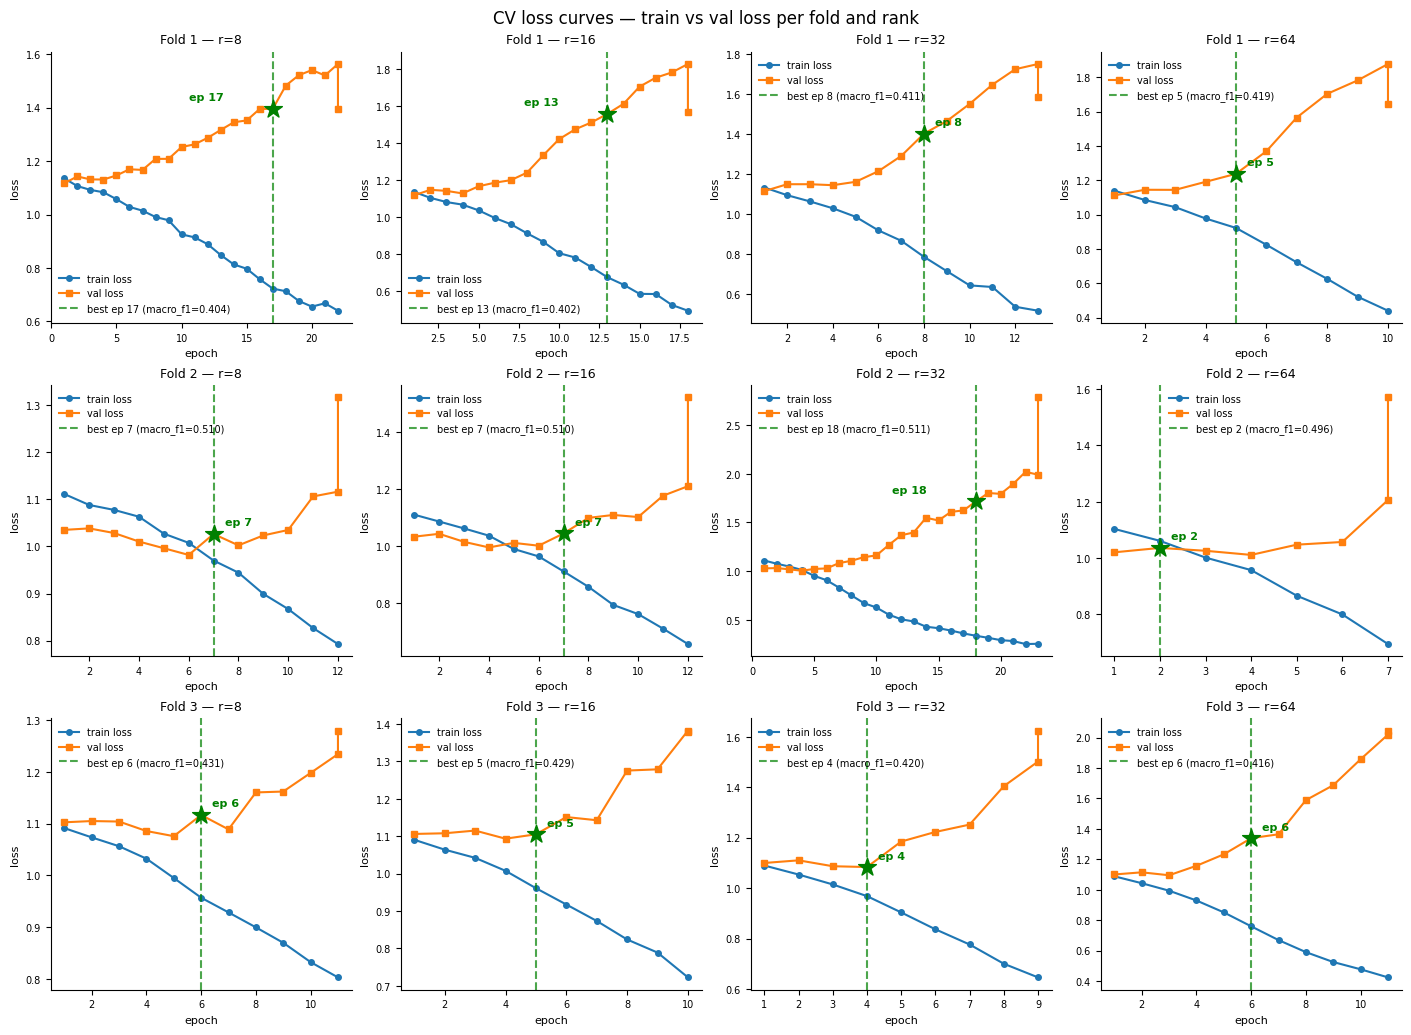

In [ ]:
# [training path] — plots the CV runs from the cell above (needs the CV)
# CV loss curves
FOLDS = sorted({f for f, _ in cv_histories})
RANKS = sorted({r for _, r in cv_histories})
fig, axes = plt.subplots(len(FOLDS), len(RANKS), figsize=(14, 10), constrained_layout=True)
fig.suptitle("CV loss curves — train vs val loss per fold and rank", fontsize=12, y=1.02)
for row, fold in enumerate(FOLDS):
    for col, rank in enumerate(RANKS):
        hist = cv_histories.get((fold, rank))
        ax = axes[row][col]
        if hist is None:
            ax.set_visible(False)
            continue
        plot_loss_curves(hist, title=f"Fold {fold} — r={rank}", ax=ax)
plt.show()


Macro-F1 by Stage-2 rank and fold:
      fold 1  fold 2  fold 3   mean    std
rank                                      
8      0.427   0.415   0.411  0.417  0.008
16     0.441   0.409   0.388  0.412  0.027
32     0.423   0.387   0.403  0.404  0.018
64     0.443   0.376   0.401  0.407  0.034

Best rank by CV mean: r=8  (0.417 ± 0.008)

Model 2 recipe (r=32) CV macro-F1: 0.404 ± 0.018
Model 2 single-split test macro-F1: 0.397 → inside the CV mean ± std band
Chance macro-F1 floor (stratified dummy): 0.320


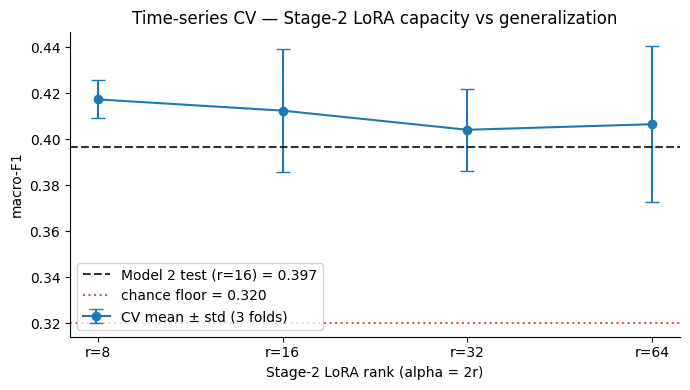

In [ ]:
# [training path] — summarizes the CV runs above (needs the CV)
# CV results: 4×3 table (rank × fold), mean ± std per rank, comparison with Model 2's test score

cv_results = pd.DataFrame(cv_records)
table = cv_results.pivot(index="rank", columns="fold", values="macro_f1")
table.columns = [f"fold {c}" for c in table.columns]
table["mean"] = table.mean(axis=1)
table["std"]  = table[[c for c in table.columns if c.startswith("fold")]].std(axis=1)
print("Macro-F1 by Stage-2 rank and fold:")
print(table.round(3).to_string())

best_rank_cv = table["mean"].idxmax()
print(f"\nBest rank by CV mean: r={best_rank_cv}  "
      f"({table.loc[best_rank_cv, 'mean']:.3f} ± {table.loc[best_rank_cv, 'std']:.3f})")

# Overfitting check: the r=16 row is the CV estimate of the ACTUAL Model 2 recipe
m16_mean, m16_std = table.loc[16, "mean"], table.loc[16, "std"]
print(f"\nModel 2 recipe (r=16) CV macro-F1: {m16_mean:.3f} ± {m16_std:.3f}")
if "m2_macro_f1" in globals():
    inside = abs(m2_macro_f1 - m16_mean) <= m16_std
    print(f"Model 2 single-split test macro-F1: {m2_macro_f1:.3f} "
          f"→ {'inside' if inside else 'OUTSIDE'} the CV mean ± std band")
if "baseline_rows" in globals():
    print(f"Chance macro-F1 floor (stratified dummy): {baseline_rows['stratified'][1]:.3f}")

# Plot: mean ± std per rank, with the Model 2 test score and chance floor as references
fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(table.index, table["mean"], yerr=table["std"],
            marker="o", capsize=5, color="tab:blue", label="CV mean ± std (3 folds)")
if "m2_macro_f1" in globals():
    ax.axhline(m2_macro_f1, ls="--", color="black", alpha=0.8,
               label=f"Model 2 test (r=16) = {m2_macro_f1:.3f}")
if "baseline_rows" in globals():
    ax.axhline(baseline_rows["stratified"][1], ls=":", color="tab:red", alpha=0.8,
               label=f"chance floor = {baseline_rows['stratified'][1]:.3f}")
ax.set_xscale("log", base=2)
ax.set_xticks(list(table.index))
ax.set_xticklabels([f"r={r}" for r in table.index])
ax.set_xlabel("Stage-2 LoRA rank (alpha = 2r)")
ax.set_ylabel("macro-F1")
ax.set_title("Time-series CV — Stage-2 LoRA capacity vs generalization")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# 8. Conclusions

**Best model: Model 1 (linear probe on frozen Stage-1 features) — test macro-F1 0.415 / accuracy 0.425.**


| Model | Accuracy | Macro-F1 | vs chance F1 (0.320) |
|---|---|---|---|
| Majority class (most_frequent) | 0.236 | 0.127 | — |
| Stratified random (50 seeds) | 0.326 | 0.320 | floor |
| **Model 1 — linear probe** | **0.425** | **0.415** | **+30%** |
| Model 2 — stacked LoRA + head | 0.409 | 0.397 | +24% |

**What happened, step by step:**

1. **Stage 1 worked**: BERT + LoRA fine-tuned on Twitter financial sentiment reached **0.877 accuracy / 0.841 macro-F1** on its held-out tweets. We can say that the backbone genuinely learned financial-sentiment representations.
2. **The frozen features transfer**: Model 1 trains only a linear head on the price-derived labels and scores macro-F1 **0.415**, **+30%** over the empirical chance floor of 0.320. Sentiment features carry real signal about same-day price direction, and a single linear layer on top of them is enough to extract it.
3. **Adapting the representation does NOT help**: Model 2 stacks another LoRA on the frozen Stage-1 adapter, yet **loses 0.018 macro-F1** versus the probe (0.397 vs 0.415). The extra trainable capacity buys no extra generalization on our dataset
4. **More capacity adds variance, not accuracy/f1-score**: Time-series CV across Stage-2 ranks: **0.417 ± 0.008 (r=8), 0.412 ± 0.027 (r=16), 0.404 ± 0.018 (r=32), 0.407 ± 0.034 (r=64)**. The means are flat and the *smallest* adapter is best with the *tightest* band, i.e. larger ranks mainly inflate the std (up to 0.034). Even the best-tuned stacked LoRA (r=8, 0.417) only ties the linear probe (0.415). 

**Why performance caps at ~0.42**: for us the bottleneck is the labels, not in the model, i.e. treshold is the same-day ±1% close-to-close move, so:  
1. one fixed threshold is applied to stocks with very different volatilities (ex. KO vs TSLA), so the same % move does not mean the same thing for each ticker
2. we have more headlines which share the same single day-label capping how cleanly any model can separate the classes

**Takeaway.** Both models beat chance decisively, so news headlines do contain exploitable signal. The clearest evidence: the cheapest model (frozen features + one linear layer) is the best, and adding an adaptive LoRA on top only adds variance.

# Appendix — save trained models to Google Drive (one-off)

Executed once after training Model 1 and Model 2 — the files are already in
`MyDrive/gsom_models`. Kept for reproducibility; no need to run it again.

In [ ]:
# Save all trained model parameters to Google Drive 
# Run this AFTER both Model 1 and Model 2

import os, torch
from google.colab import drive

drive.mount("/content/drive")

SAVE_DIR = "/content/drive/MyDrive/gsom_models"
os.makedirs(SAVE_DIR, exist_ok=True)

# tokenizer (identical for both models) — handy for a clean reload later
bert_tokenizer.save_pretrained(f"{SAVE_DIR}/tokenizer")

# ── Model 1: Stage-1 LoRA ("default" adapter) + trained linear-probe head ──
bert_model.save_pretrained(f"{SAVE_DIR}/model1")                      # adapter "default"
torch.save(bert_model.classifier.state_dict(), f"{SAVE_DIR}/model1_head.pt")

# ── Model 2: two adapters ("default" frozen + "stage2" trained) + retrained head ──
bert_model_m2.save_pretrained(                                       # both adapters
    f"{SAVE_DIR}/model2", selected_adapters=["default", "stage2"]
)
torch.save(bert_model_m2.classifier.state_dict(), f"{SAVE_DIR}/model2_head.pt")

print("Saved to", SAVE_DIR)
for root, _, files in os.walk(SAVE_DIR):
    for f in sorted(files):
        print(" ", os.path.join(root, f))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved to /content/drive/MyDrive/gsom_models
  /content/drive/MyDrive/gsom_models/model1_head.pt
  /content/drive/MyDrive/gsom_models/model2_head.pt
  /content/drive/MyDrive/gsom_models/tokenizer/tokenizer.json
  /content/drive/MyDrive/gsom_models/tokenizer/tokenizer_config.json
  /content/drive/MyDrive/gsom_models/model1/README.md
  /content/drive/MyDrive/gsom_models/model1/adapter_config.json
  /content/drive/MyDrive/gsom_models/model1/adapter_model.safetensors
  /content/drive/MyDrive/gsom_models/model2/README.md
  /content/drive/MyDrive/gsom_models/model2/adapter_config.json
  /content/drive/MyDrive/gsom_models/model2/adapter_model.safetensors
  /content/drive/MyDrive/gsom_models/model2/stage2/adapter_config.json
  /content/drive/MyDrive/gsom_models/model2/stage2/adapter_model.safetensors
